### 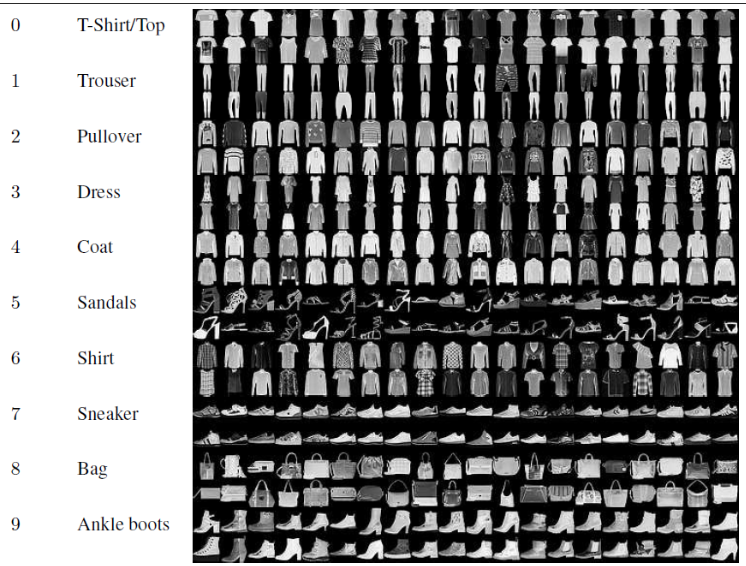

In [3]:
import tensorflow as tf

In [1]:
import pandas as pd

In [2]:
import numpy as np

In [17]:
import matplotlib.pyplot as plt

In [4]:
from tensorflow.keras.models import Model

In [6]:
from tensorflow.keras.layers import Input, Flatten, Dense

In [7]:
from tensorflow.keras.datasets import fashion_mnist

In [9]:
(X_train, y_train), (X_test, y_test ) = fashion_mnist.load_data()

In [10]:
X_train.shape

(60000, 28, 28)

In [11]:
X_test.shape

(10000, 28, 28)

In [12]:
names = ["T-Shirt", "Trouser", "Pull Over", "Dess", "Coat", "Sandal", "Shirt", "Sneakers", "Bag", "Ankle Boots"]

In [13]:
names

['T-Shirt',
 'Trouser',
 'Pull Over',
 'Dess',
 'Coat',
 'Sandal',
 'Shirt',
 'Sneakers',
 'Bag',
 'Ankle Boots']

In [19]:
X_train[1000]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  97,  84,
         97, 110, 108,  87,  97,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  19, 255, 199,
        183, 142, 161, 200, 213,  32,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  72, 174, 173,
        158, 131, 132, 176, 176,  70,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 142, 180, 163,
        120, 180, 126, 139, 168, 122,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 156, 180, 162,
        171, 170, 183, 163, 169, 144,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 159, 177, 163,
        174, 166, 173, 170, 163, 148,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  

In [20]:
y_train[1000]

np.uint8(1)

In [21]:
names[1]

'Trouser'

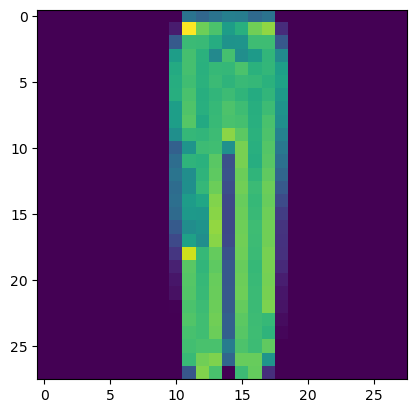

In [22]:
plt.imshow(X_train[1000])

In [23]:
X_test.shape

(10000, 28, 28)

In [24]:
X_test[5000]

array([[  0,   0,   0,   0,   1,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   1,   1,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   2,  96, 224, 120,  59,
         59,  57,  63, 127, 216,  46,   0,   0,   0,   1,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 161, 233, 221, 215, 249, 249,
        234, 233, 248, 242, 205, 231, 195,  63,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 176, 251, 222, 225, 204, 190, 201,
        207, 208, 199, 194, 220, 227, 235, 245,  71,   0,   1,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  15, 233, 226, 226, 225, 239, 240, 227,
        218, 209, 219, 239, 228, 225, 223, 241, 175,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,  77, 249, 226, 230, 229, 228, 219, 164,
        171, 246, 223, 222, 223, 230, 229, 234, 219,   0,   0,   0,   0,
          0,   0],
       [  

In [25]:
y_test[5000]

np.uint8(2)

In [26]:
names[2]

'Pull Over'

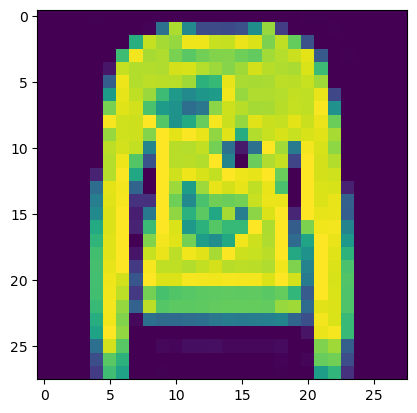

In [27]:
plt.imshow(X_test[5000])

### Scaling

In [28]:
X_train.max()

np.uint8(255)

In [29]:
X_train.min()

np.uint8(0)

In [30]:
X_test.max()

np.uint8(255)

In [31]:
X_test.min()

np.uint8(0)

In [32]:
X_train_scale = X_train/ 255

In [33]:
X_test_scale = X_test / 255

In [34]:
X_train_scale.max()

np.float64(1.0)

In [35]:
X_test_scale.max()

np.float64(1.0)

In [36]:
X_train_scale.min()

np.float64(0.0)

In [37]:
X_test_scale.min()

np.float64(0.0)

In [38]:
X_train[500]

array([[  0,   0,   0,   0,   0,   0,   0,   3,   0,   0,   0,  19, 204,
         93,  35,  91, 227,  91,   0,   0,   0,   3,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   2,   0,   0, 134, 210, 237, 241,
        241, 255, 245, 238, 241, 248, 111,   0,   0,   3,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 175, 254, 235, 233, 232,
        225, 227, 226, 229, 231, 236, 250, 200,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   2, 240, 229, 228, 219, 215,
        235, 229, 234, 217, 198, 222, 220, 255, 101,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  46, 246, 236, 189, 173, 212,
        240, 226, 239, 210, 152, 177, 222, 249, 170,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  97, 255, 233, 226, 231, 237,
        230, 231, 231, 236, 241, 232, 231, 245, 210,   0,   0,   0,   0,
          0,   0],
       [  

In [39]:
X_train_scale[500]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.01176471, 0.        , 0.        ,
        0.        , 0.0745098 , 0.8       , 0.36470588, 0.1372549 ,
        0.35686275, 0.89019608, 0.35686275, 0.        , 0.        ,
        0.        , 0.01176471, 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.00784314, 0.        , 0.        , 0.5254902 ,
        0.82352941, 0.92941176, 0.94509804, 0.94509804, 1.        ,
        0.96078431, 0.93333333, 0.94509804, 0.97254902, 0.43529412,
        0.        , 0.        , 0.01176471, 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.68627451, 0.99607843,
        0.92156863, 0.91372549, 0.90980392, 0.88235294, 0.89019608,
        0.88627451, 0.8980

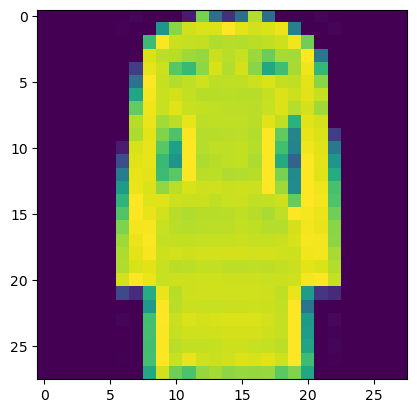

In [40]:
plt.imshow(X_train[500])

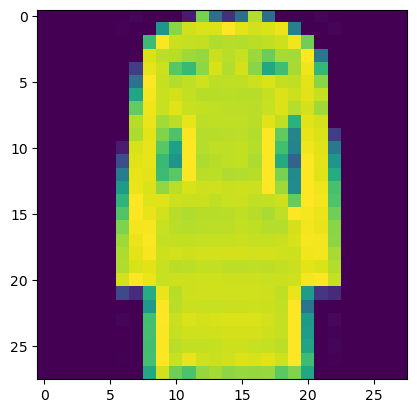

In [41]:
plt.imshow(X_train_scale[500])

In [42]:
X_train.shape

(60000, 28, 28)

In [43]:
X_train_scale.shape

(60000, 28, 28)

In [44]:
X_test.shape

(10000, 28, 28)

In [45]:
X_test_scale.shape

(10000, 28, 28)

### Functional Model

In [46]:
from tensorflow.keras.models import Model

In [47]:
from tensorflow.keras.layers import Input, Dense, Flatten

In [48]:
X_train_scale.shape

(60000, 28, 28)

In [49]:
ip = Input(shape = (28,28))

In [50]:
flat = Flatten()(ip)

In [51]:
den1 = Dense(64, activation = "relu")(flat)

In [52]:
den2 = Dense(128, activation = "relu")(den1)

In [53]:
den3 = Dense(256, activation = "relu")(den2)

In [54]:
den4 = Dense(128, activation = "relu")(den3)

In [55]:
den5 = Dense(64, activation = "relu")(den4)

In [56]:
out = Dense(10, activation = "softmax")(den5)

In [57]:
fmodel = Model(inputs = ip, outputs = out)

In [58]:
fmodel.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 28, 28)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 784)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │          50,240 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 256)                 │          33,024 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 133,386 (521.04 KB)

 Trainable params: 133,386 (521.04 KB)

 Non-trainable params: 0 (0.00 B)

In [59]:
fmodel.compile(
                optimizer = "adam",
                loss = "sparse_categorical_crossentropy",
                metrics = ['accuracy']                        
                    )

In [61]:
fmodel.fit(X_train_scale, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9056 - loss: 0.2484
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9084 - loss: 0.2423
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9110 - loss: 0.2336
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9129 - loss: 0.2305
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9154 - loss: 0.2234
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9168 - loss: 0.2185
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.9189 - loss: 0.2126
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.9215 - loss: 0.2072
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.9236 - loss: 0.2036
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 7ms/step - accuracy: 0.9240 - loss: 0.2000


In [63]:
fmodel.evaluate(X_test_scale, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.8992 - loss: 0.2774 


[0.2773744463920593, 0.8992000222206116]

### Prediction-01

In [65]:
X_train_scale[21]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.03529412, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.01568627,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.02352941,
        0.11764706, 0.01176471, 0.01568627, 0.01568627, 0.05098039,
        0.08235294, 0.11764706, 0.19215686, 0.12156863, 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.61960784,
        0.89803922, 0.83921569, 0.84313725, 0.81568627, 0.83137255,
        0.84313725, 0.8392

In [66]:
X_train_scale[21].shape

(28, 28)

In [67]:
X_train_scale[21].reshape(1,28,28)

array([[[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.03529412, 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.01568627,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.02352941,
         0.11764706, 0.01176471, 0.01568627, 0.01568627, 0.05098039,
         0.08235294, 0.11764706, 0.19215686, 0.12156863, 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.61960784,
         0.89803922, 0.83921569, 0.84313725, 0.81568627, 0.83137255,
         0.

In [68]:
image1 = X_train_scale[21].reshape(1,28,28)

In [75]:
image1.shape

(1, 28, 28)

In [76]:
fmodel.predict(image1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step


array([[4.5941425e-07, 9.9997199e-01, 1.6929005e-09, 2.0054311e-05,
        6.3499638e-06, 1.5827431e-21, 1.1214329e-06, 5.2828658e-24,
        2.7530039e-10, 6.5643100e-16]], dtype=float32)

In [77]:
np.argmax(fmodel.predict(image1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step


np.int64(1)

In [78]:
y_train[21]

np.uint8(1)

In [79]:
names[1]

'Trouser'

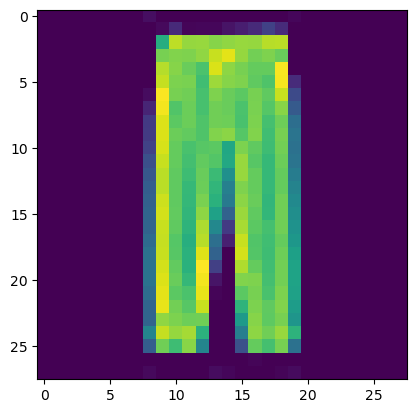

In [80]:
plt.imshow(X_train[21])

### Prediction - 2

In [82]:
X_test_scale[100]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.1372549 ,
        0.29803922, 0.28235294, 0.        , 0.        , 0.        ,
        0.        , 0.31764706, 0.29803922, 0.00784314, 0.07058824,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.38431373, 0.81176471,
        0.94117647, 0.71372549, 0.37647059, 0.50980392, 0.54117647,
        0.42352941, 0.58823529, 0.74901961, 0.75686275, 0.6745098 ,
        0.30588235, 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.23137255, 0.61176471, 0.58823529,
        0.8745098 , 0.76078431, 0.80784314, 0.52941176, 0.50980392,
        0.25882353, 0.0392

In [83]:
X_test_scale[100].reshape(1, 28, 28)

array([[[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.1372549 ,
         0.29803922, 0.28235294, 0.        , 0.        , 0.        ,
         0.        , 0.31764706, 0.29803922, 0.00784314, 0.07058824,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.38431373, 0.81176471,
         0.94117647, 0.71372549, 0.37647059, 0.50980392, 0.54117647,
         0.42352941, 0.58823529, 0.74901961, 0.75686275, 0.6745098 ,
         0.30588235, 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.23137255, 0.61176471, 0.58823529,
         0.8745098 , 0.76078431, 0.80784314, 0.52941176, 0.50980392,
         0.

In [84]:
image2 = X_test_scale[100].reshape(1, 28, 28)

In [85]:
image2

array([[[0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.        , 0.1372549 ,
         0.29803922, 0.28235294, 0.        , 0.        , 0.        ,
         0.        , 0.31764706, 0.29803922, 0.00784314, 0.07058824,
         0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        , 0.38431373, 0.81176471,
         0.94117647, 0.71372549, 0.37647059, 0.50980392, 0.54117647,
         0.42352941, 0.58823529, 0.74901961, 0.75686275, 0.6745098 ,
         0.30588235, 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.        ],
        [0.        , 0.        , 0.        , 0.        , 0.        ,
         0.        , 0.        , 0.23137255, 0.61176471, 0.58823529,
         0.8745098 , 0.76078431, 0.80784314, 0.52941176, 0.50980392,
         0.

In [86]:
image2.shape

(1, 28, 28)

In [88]:
fmodel.predict(image2)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step


array([[5.8893259e-03, 1.6446030e-03, 7.9391326e-04, 9.8132080e-01,
        4.3662090e-04, 3.7262129e-10, 9.9079739e-03, 3.7047787e-12,
        6.6552352e-06, 7.7908183e-12]], dtype=float32)

In [89]:
np.argmax(fmodel.predict(image2))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 113ms/step


np.int64(3)

In [90]:
names[3]

'Dess'

In [91]:
y_test[100]

np.uint8(3)

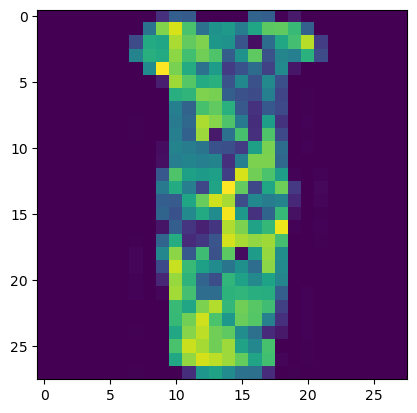

In [92]:
plt.imshow(X_test_scale[100])